# Perturbation Magnitude Analysis

In [44]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from model import lqg_model

plt.rcParams['figure.dpi'] = 300
%matplotlib inline

COLORS = ["lightsteelblue",'orange', 'indianred', 'mediumorchid', 'darkseagreen', 'goldenrod']

## LQG Model Parameters & Initialization

In [45]:
horizon = 3000
T_p = 100
T_v = 0

lqg_baseline = lqg_model.LQG(horizon, target=[T_p, T_v])

x0 = np.matrix([[0], [0]])
dt = 0.01

A  = np.matrix([[1, dt], [0,  1]])
B  = np.matrix([[0],     [dt]])
C  = np.matrix([[1, 0],  [0,  1]])
Q  = np.matrix([[500, 0], [0, 1]])
R  = np.matrix([[0.0001]])
V  = np.matrix([[0.001, 0], [0, 0.001]])
W  = np.matrix([[1.5,  0], [0, 1.5]])
X0 = np.matrix([[0.1,  0], [0, 0.1]])

lqg_baseline.define('A', A)
lqg_baseline.define('B', B)
lqg_baseline.define('C', C)
lqg_baseline.define('Q', Q)
lqg_baseline.define('R', R)
lqg_baseline.define('V', V)
lqg_baseline.define('W', W)
lqg_baseline.define('X', X0)

lqg_baseline.kalman()
lqg_baseline.control()

print(f'Horizon: {horizon} steps ({horizon*dt:.0f}s),  dt={dt}s')

Horizon: 3000 steps (30s),  dt=0.01s


## Baseline Simulation

In [46]:
np.random.seed(42)

v_noise = [np.random.randn(2, 1) for _ in range(horizon)]
w_noise = [np.random.randn(2, 1) for _ in range(horizon)]

x_baseline_list    = [x0.copy()]
xhat_baseline_list = [x0.copy()]
u_baseline_list    = []

target = np.matrix([[T_p], [T_v]])

for t in range(horizon - 1):
    u_t    = lqg_baseline.var['K'][t] * (xhat_baseline_list[t] - target)
    u_baseline_list.append(u_t)
    x_next = A * x_baseline_list[t] + B * u_t + V * np.matrix(v_noise[t])
    x_baseline_list.append(x_next)
    y      = C * x_next + W * np.matrix(w_noise[t + 1])
    xhat_pred = A * xhat_baseline_list[t] + B * u_t
    xhat_baseline_list.append(xhat_pred + lqg_baseline.var['L'][t] * (y - C * xhat_pred))

u_baseline_list.append(lqg_baseline.var['K'][horizon - 1] * (xhat_baseline_list[-1] - target))

x_baseline    = np.array([x_baseline_list[t][0, 0]    for t in range(horizon)])
xhat_baseline = np.array([xhat_baseline_list[t][0, 0] for t in range(horizon)])

baseline_data = {
    'x':   x_baseline_list,
    'kf':  {'x1': xhat_baseline_list},
    'u':   u_baseline_list,
    'noise': {
        'v': [np.matrix(v_noise[t]) for t in range(horizon)],
        'w': [np.matrix(w_noise[t]) for t in range(horizon)]
    }
}

print(f'baseline final:  x={x_baseline[-1]:.4f},  xhat={xhat_baseline[-1]:.4f}')

baseline final:  x=99.9639,  xhat=99.9986


## Perturbation Magnitude Sweep

In [47]:
perturbation_start = 200
perturbation_end   = 250
xhat_pulse_end     = perturbation_end  # same window as u perturbation

u_pert_magnitudes = [-1.5, -1.0, -0.5, -0.25]


def simulate_u_pert(u_magnitude):
    v_n = baseline_data['noise']['v']
    w_n = baseline_data['noise']['w']
    x_list    = [baseline_data['x'][t].copy()        for t in range(perturbation_start + 1)]
    xhat_list = [baseline_data['kf']['x1'][t].copy() for t in range(perturbation_start + 1)]
    for t in range(perturbation_start, horizon - 1):
        u_t = lqg_baseline.var['K'][t] * (xhat_list[t] - target)
        if perturbation_start <= t < perturbation_end:
            u_t = u_t + u_magnitude
        x_next = A * x_list[t] + B * u_t + V * v_n[t]
        x_list.append(x_next)
        y         = C * x_next + W * w_n[t + 1]
        xhat_pred = A * xhat_list[t] + B * u_t
        xhat_list.append(xhat_pred + lqg_baseline.var['L'][t] * (y - C * xhat_pred))
    return np.array([x_list[t][0, 0] for t in range(horizon)])


def simulate_xhat_pert(offset):
    v_n = baseline_data['noise']['v']
    w_n = baseline_data['noise']['w']
    x_list    = [baseline_data['x'][t].copy()        for t in range(perturbation_start + 1)]
    xhat_list = [baseline_data['kf']['x1'][t].copy() for t in range(perturbation_start + 1)]
    for t in range(perturbation_start, horizon - 1):
        u_t       = lqg_baseline.var['K'][t] * (xhat_list[t] - target)
        x_next    = A * x_list[t] + B * u_t + V * v_n[t]
        x_list.append(x_next)
        y         = C * x_next + W * w_n[t + 1]
        xhat_pred = A * xhat_list[t] + B * u_t
        xhat_next = xhat_pred + lqg_baseline.var['L'][t] * (y - C * xhat_pred)
        if perturbation_start <= (t + 1) < xhat_pulse_end:
            xhat_next[0, 0] += offset
        xhat_list.append(xhat_next)
    return np.array([x_list[t][0, 0] for t in range(horizon)])


results = {}
for mag in u_pert_magnitudes:
    x_u = simulate_u_pert(mag)
    target_dev = x_u[perturbation_end] - x_baseline[perturbation_end]

    # positive offset biases xhat high -> controller under-accelerates -> x falls below baseline
    def _dev_diff(offset, _tdev=target_dev):
        return (simulate_xhat_pert(offset)[perturbation_end] - x_baseline[perturbation_end]) - _tdev

    try:
        xhat_offset = brentq(_dev_diff, 0.001, 500.0, xtol=1e-6)
    except ValueError:
        from scipy.optimize import minimize_scalar
        xhat_offset = minimize_scalar(
            lambda o: abs(_dev_diff(o)), bounds=(0.001, 500.0), method='bounded'
        ).x

    x_xhat = simulate_xhat_pert(xhat_offset)
    results[mag] = {
        'x_u':        x_u,
        'x_xhat':     x_xhat,
        'target_dev': target_dev,
        'xhat_offset': xhat_offset,
    }
    print(f'mag={mag:+.2f}  x_dev_at_end={target_dev:.5f}  xhat_offset={xhat_offset:.5f}')

mag=-1.50  x_dev_at_end=-0.17956  xhat_offset=28.39489
mag=-1.00  x_dev_at_end=-0.11970  xhat_offset=18.92993
mag=-0.50  x_dev_at_end=-0.05985  xhat_offset=9.46496
mag=-0.25  x_dev_at_end=-0.02993  xhat_offset=4.73248


## Trajectory Plots

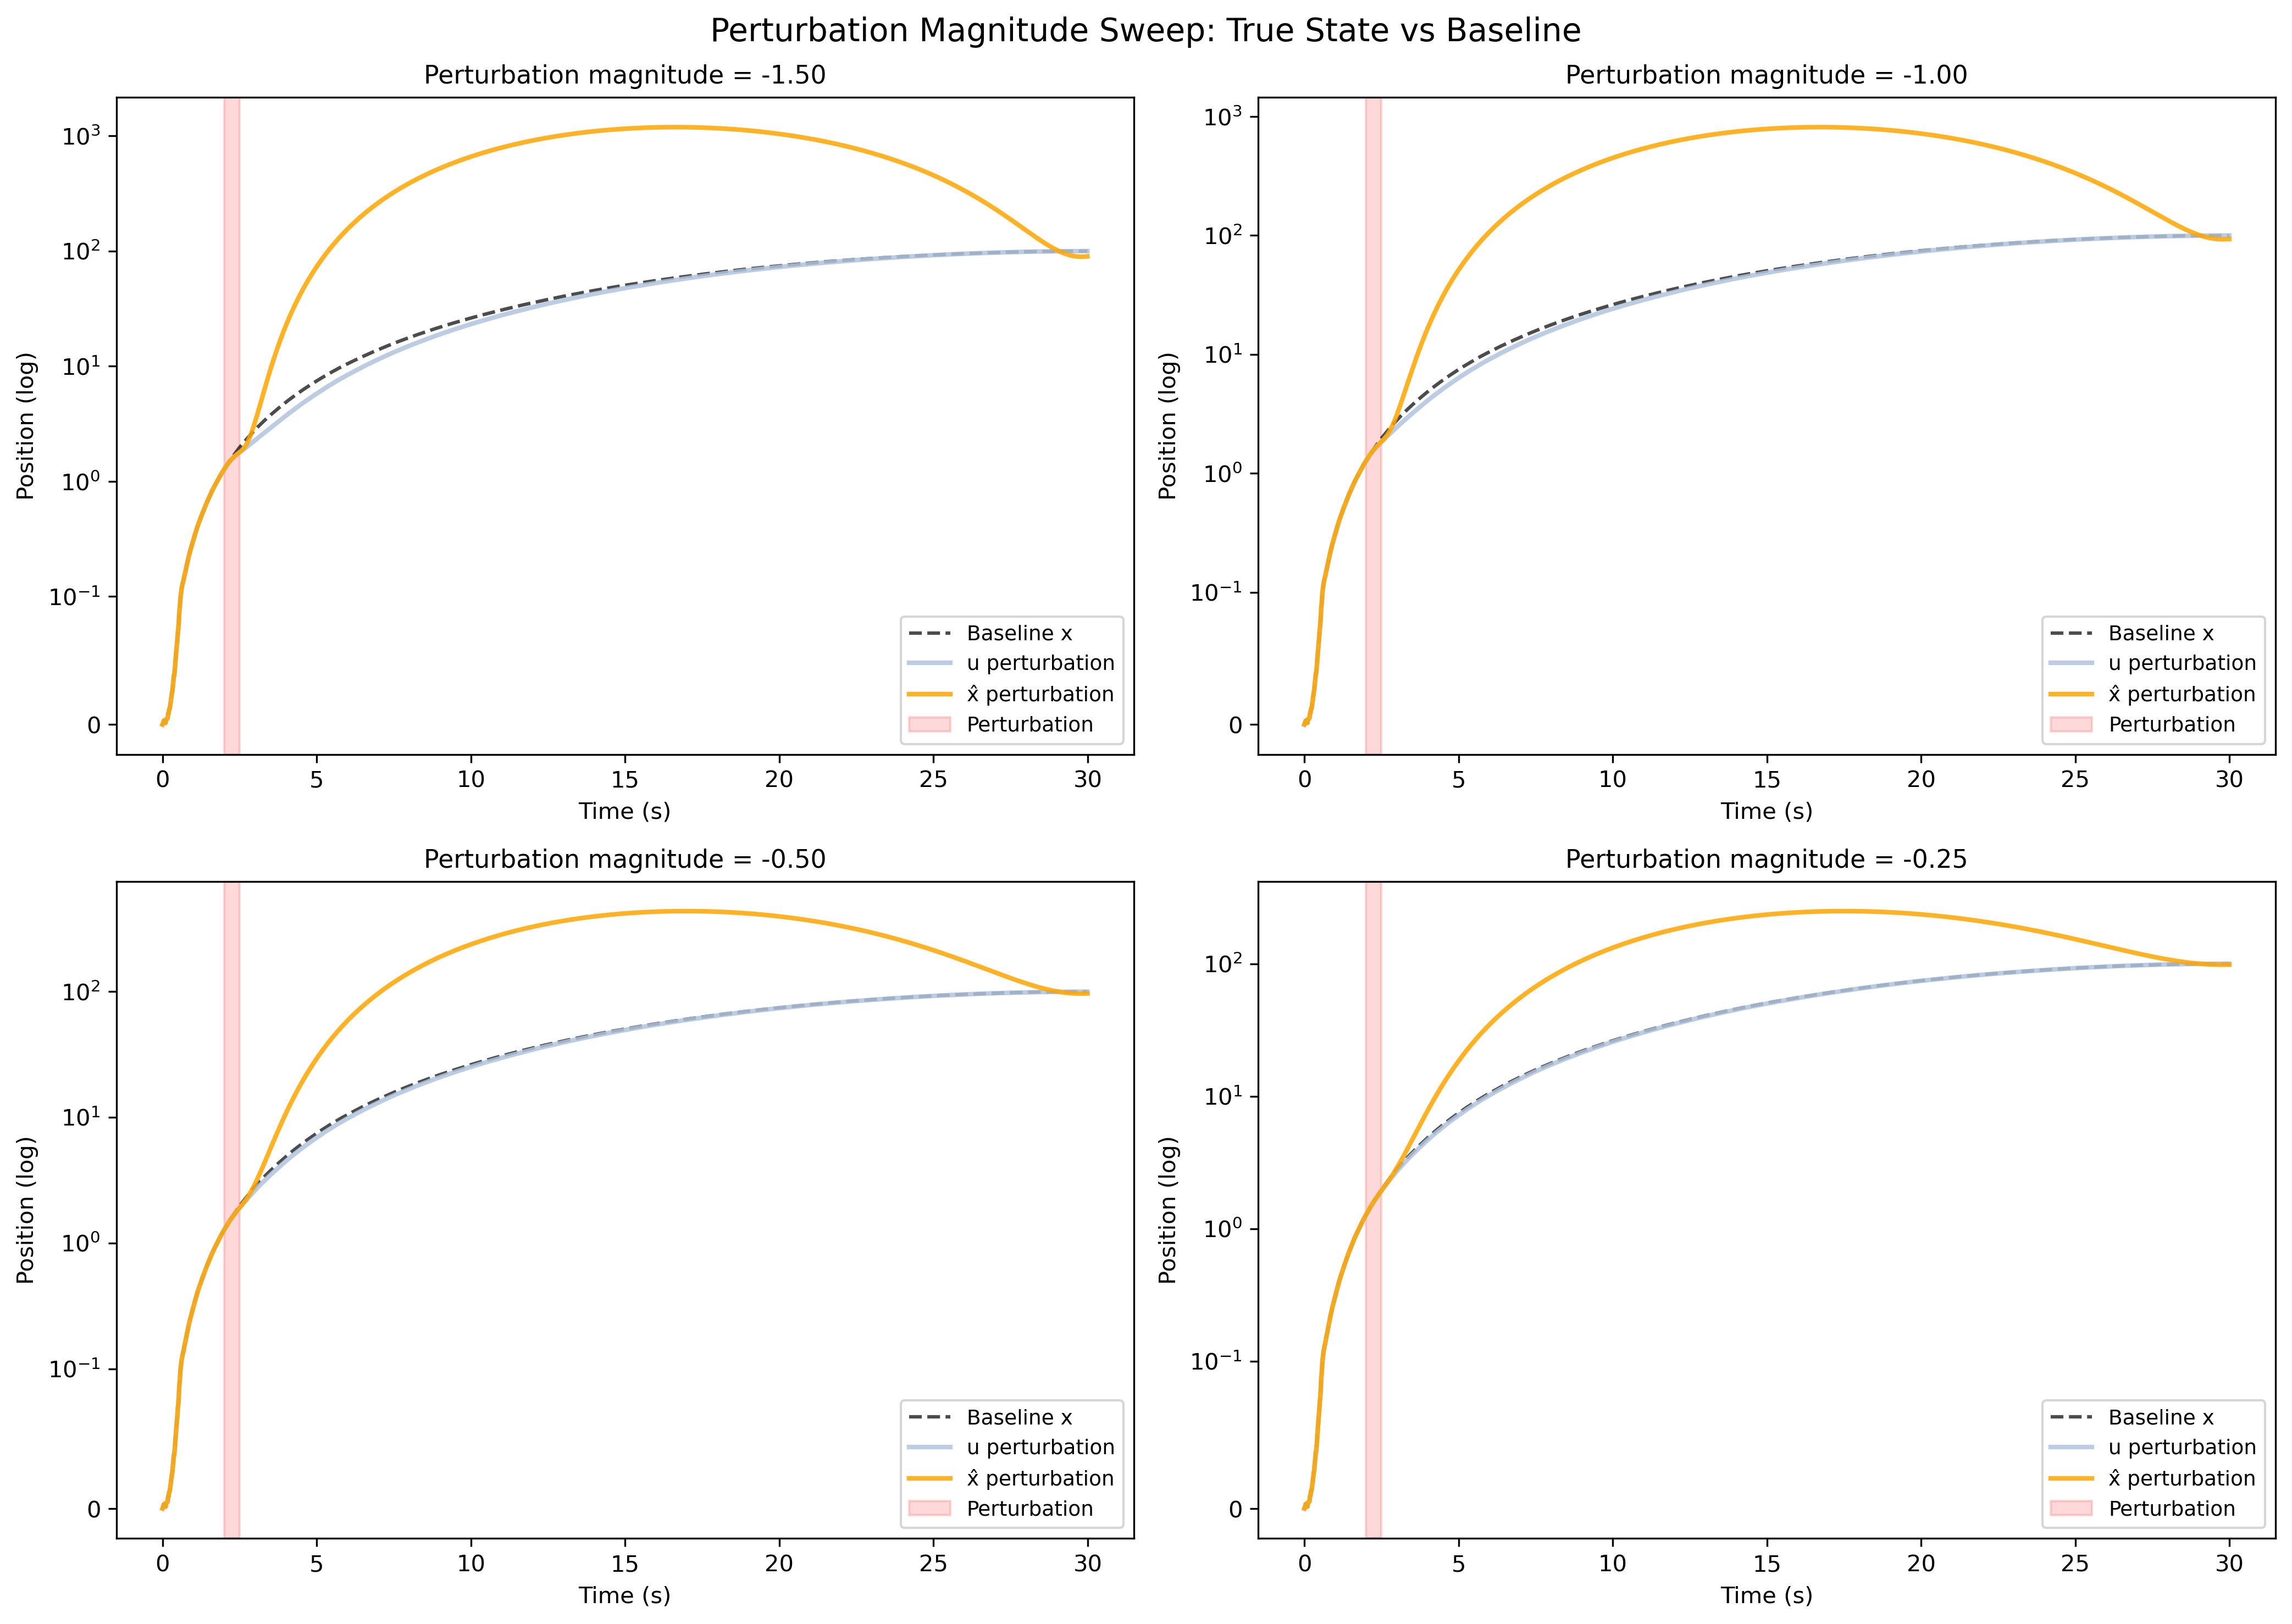

In [48]:
time = np.arange(horizon) * dt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Perturbation Magnitude Sweep: True State vs Baseline', fontsize=14, y=0.98)

for ax, mag in zip(axes.flatten(), u_pert_magnitudes):
    r = results[mag]
    ax.plot(time, x_baseline,  'k--',            linewidth=1.5, alpha=0.7,  label='Baseline x')
    ax.plot(time, r['x_u'],    color='lightsteelblue', linewidth=2,   alpha=0.85, label='u perturbation')
    ax.plot(time, r['x_xhat'], color='orange',    linewidth=2,   alpha=0.85, label='x̂ perturbation')
    ax.axvspan(perturbation_start * dt, perturbation_end * dt,
               alpha=0.15, color='red', label='Perturbation')
    ax.set_yscale('symlog', linthresh=0.1)
    ax.set_xlabel('Time (s)', fontsize=10)
    ax.set_ylabel('Position (log)', fontsize=10)
    ax.set_title(f'Perturbation magnitude = {mag:+.2f}', fontsize=11)
    ax.legend(fontsize=9)
    #ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

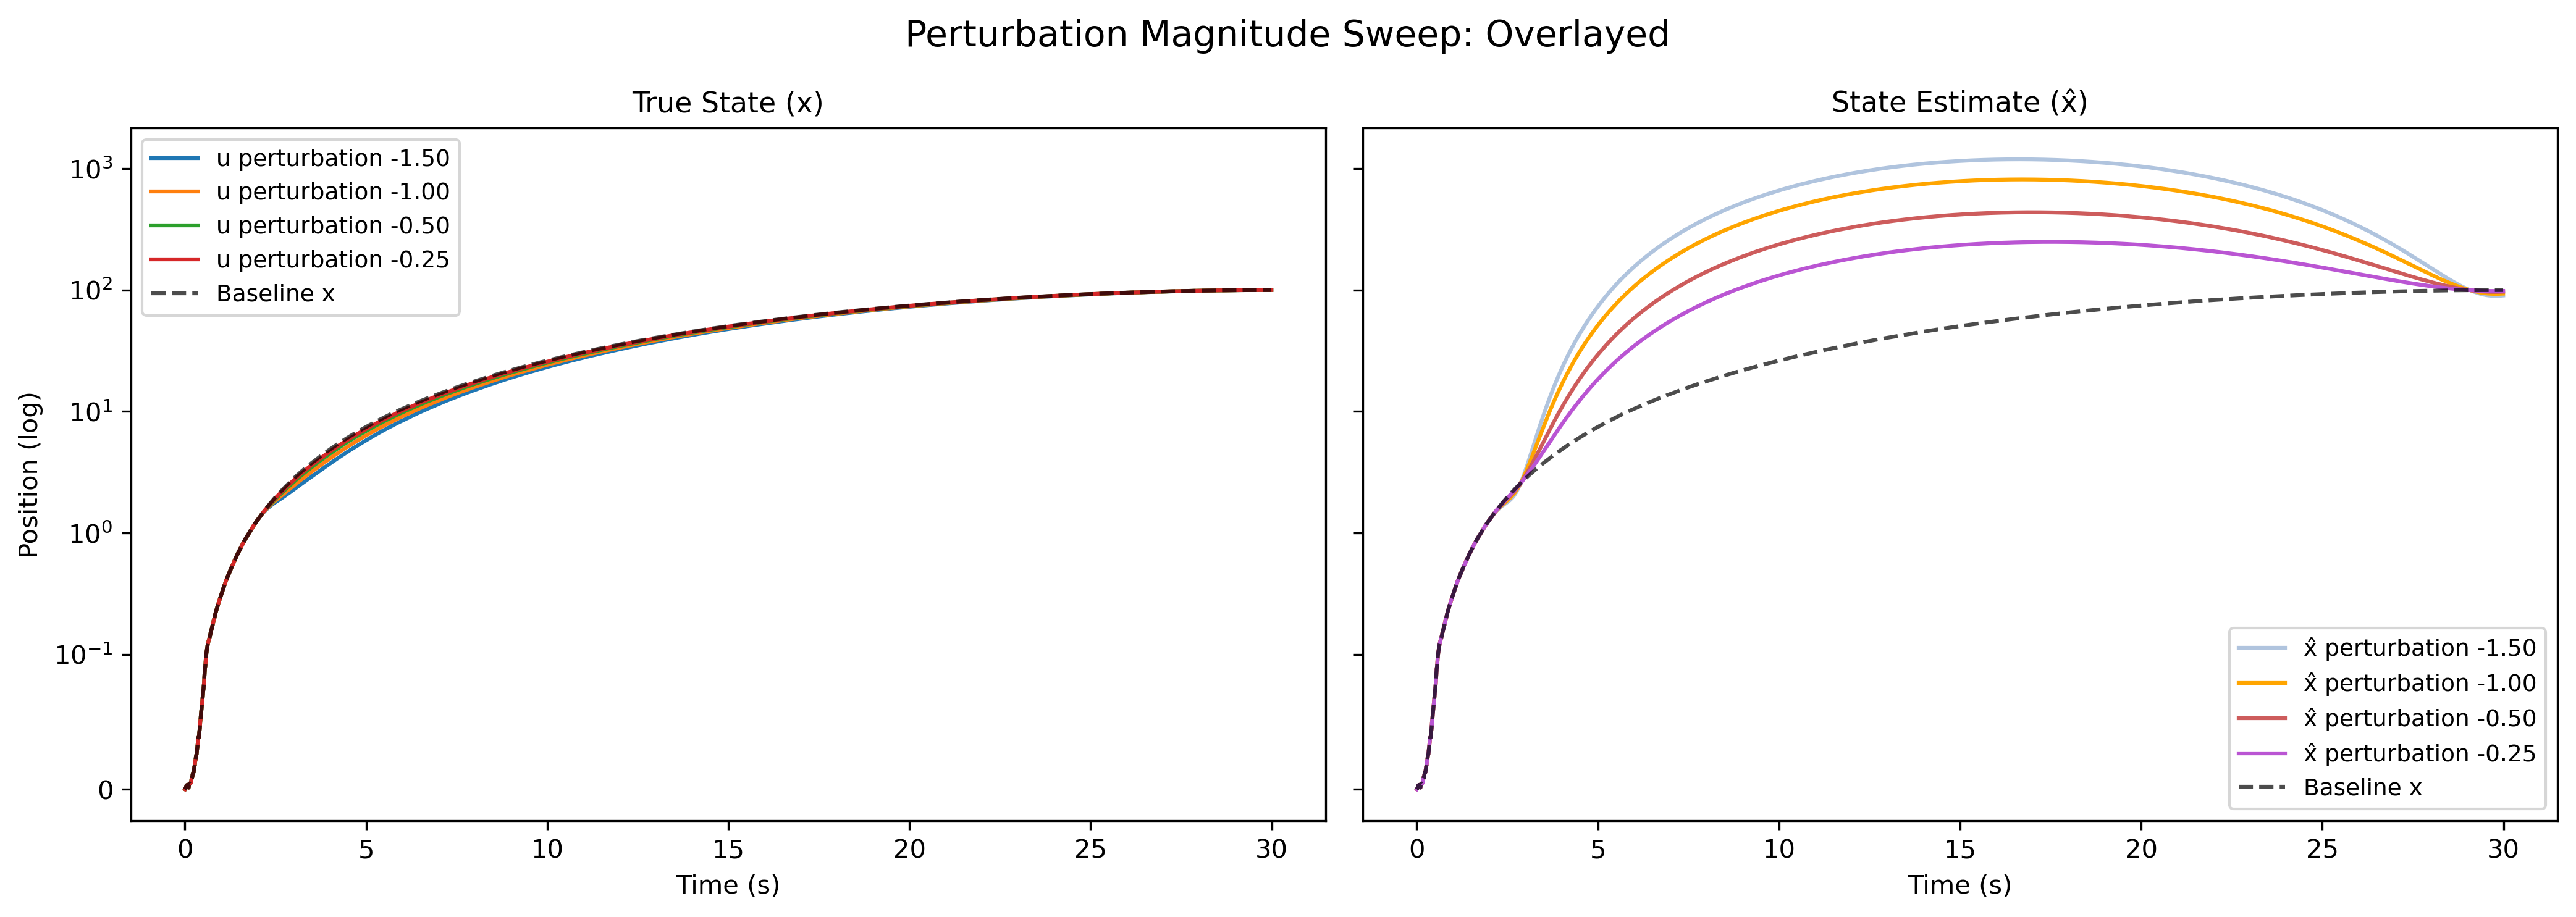

In [49]:
# overlay all plots for u and xhat perturbations
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle('Perturbation Magnitude Sweep: Overlayed', fontsize=14, y=0.98)
for i, mag in enumerate(u_pert_magnitudes):
    r = results[mag]
    axes[0].plot(time, r['x_u'], label=f'u perturbation {mag:+.2f}')
    axes[1].plot(time, r['x_xhat'], color=COLORS[i], label=f'x̂ perturbation {mag:+.2f}')
axes[0].plot(time, x_baseline, 'k--', linewidth=1.5, alpha=0.7, label='Baseline x')
axes[1].plot(time, x_baseline, 'k--', linewidth=1.5, alpha=0.7, label='Baseline x')
axes[0].set_yscale('symlog', linthresh=0.1)
axes[0].set_xlabel('Time (s)', fontsize=10)
axes[0].set_ylabel('Position (log)', fontsize=10)
axes[0].set_title('True State (x)', fontsize=11)
axes[0].legend(fontsize=9)
#axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel('Time (s)', fontsize=10)
axes[1].set_title('State Estimate (x̂)', fontsize=11)
axes[1].legend(fontsize=9)
#axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Recovery Time: % Target Accuracy Threshold

In [ ]:
def backward_settled(arr, thr, search_start):
    """first step at which arr stays permanently below thr. returns None if never settles."""
    sub = arr[search_start:horizon]
    above = np.where(sub > thr)[0]
    if len(above) == 0:
        return search_start
    if above[-1] >= len(sub) - 1:
        return None
    return search_start + above[-1] + 1

thr_pct = 10.0

rec_times_u    = []
rec_times_xhat = []

for mag in u_pert_magnitudes:
    r = results[mag]
    pct_u    = np.abs(r['x_u']    - T_p) / T_p * 100
    pct_xhat = np.abs(r['x_xhat'] - T_p) / T_p * 100

    t_u    = backward_settled(pct_u,    thr_pct, perturbation_end)
    t_xhat = backward_settled(pct_xhat, thr_pct, perturbation_end)

    rec_times_u.append(   time[t_u]    if t_u    is not None else np.nan)
    rec_times_xhat.append(time[t_xhat] if t_xhat is not None else np.nan)

rec_diff = [xh - u for xh, u in zip(rec_times_xhat, rec_times_u)]

print(f'{"Magnitude":>10}  {"u rec (s)":>10}  {"x̂ rec (s)":>10}  {"diff (s)":>10}')
for mag, ru, rx, d in zip(u_pert_magnitudes, rec_times_u, rec_times_xhat, rec_diff):
    print(f'{mag:>+10.2f}  {ru:>10.2f}  {rx:>10.2f}  {d:>+10.2f}')

 Magnitude   u rec (s)  x̂ rec (s)    diff (s)
     -1.50       24.32       29.97       +5.65
     -1.00       24.25       28.66       +4.41
     -0.50       24.17       28.33       +4.16
     -0.25       24.13       27.77       +3.64


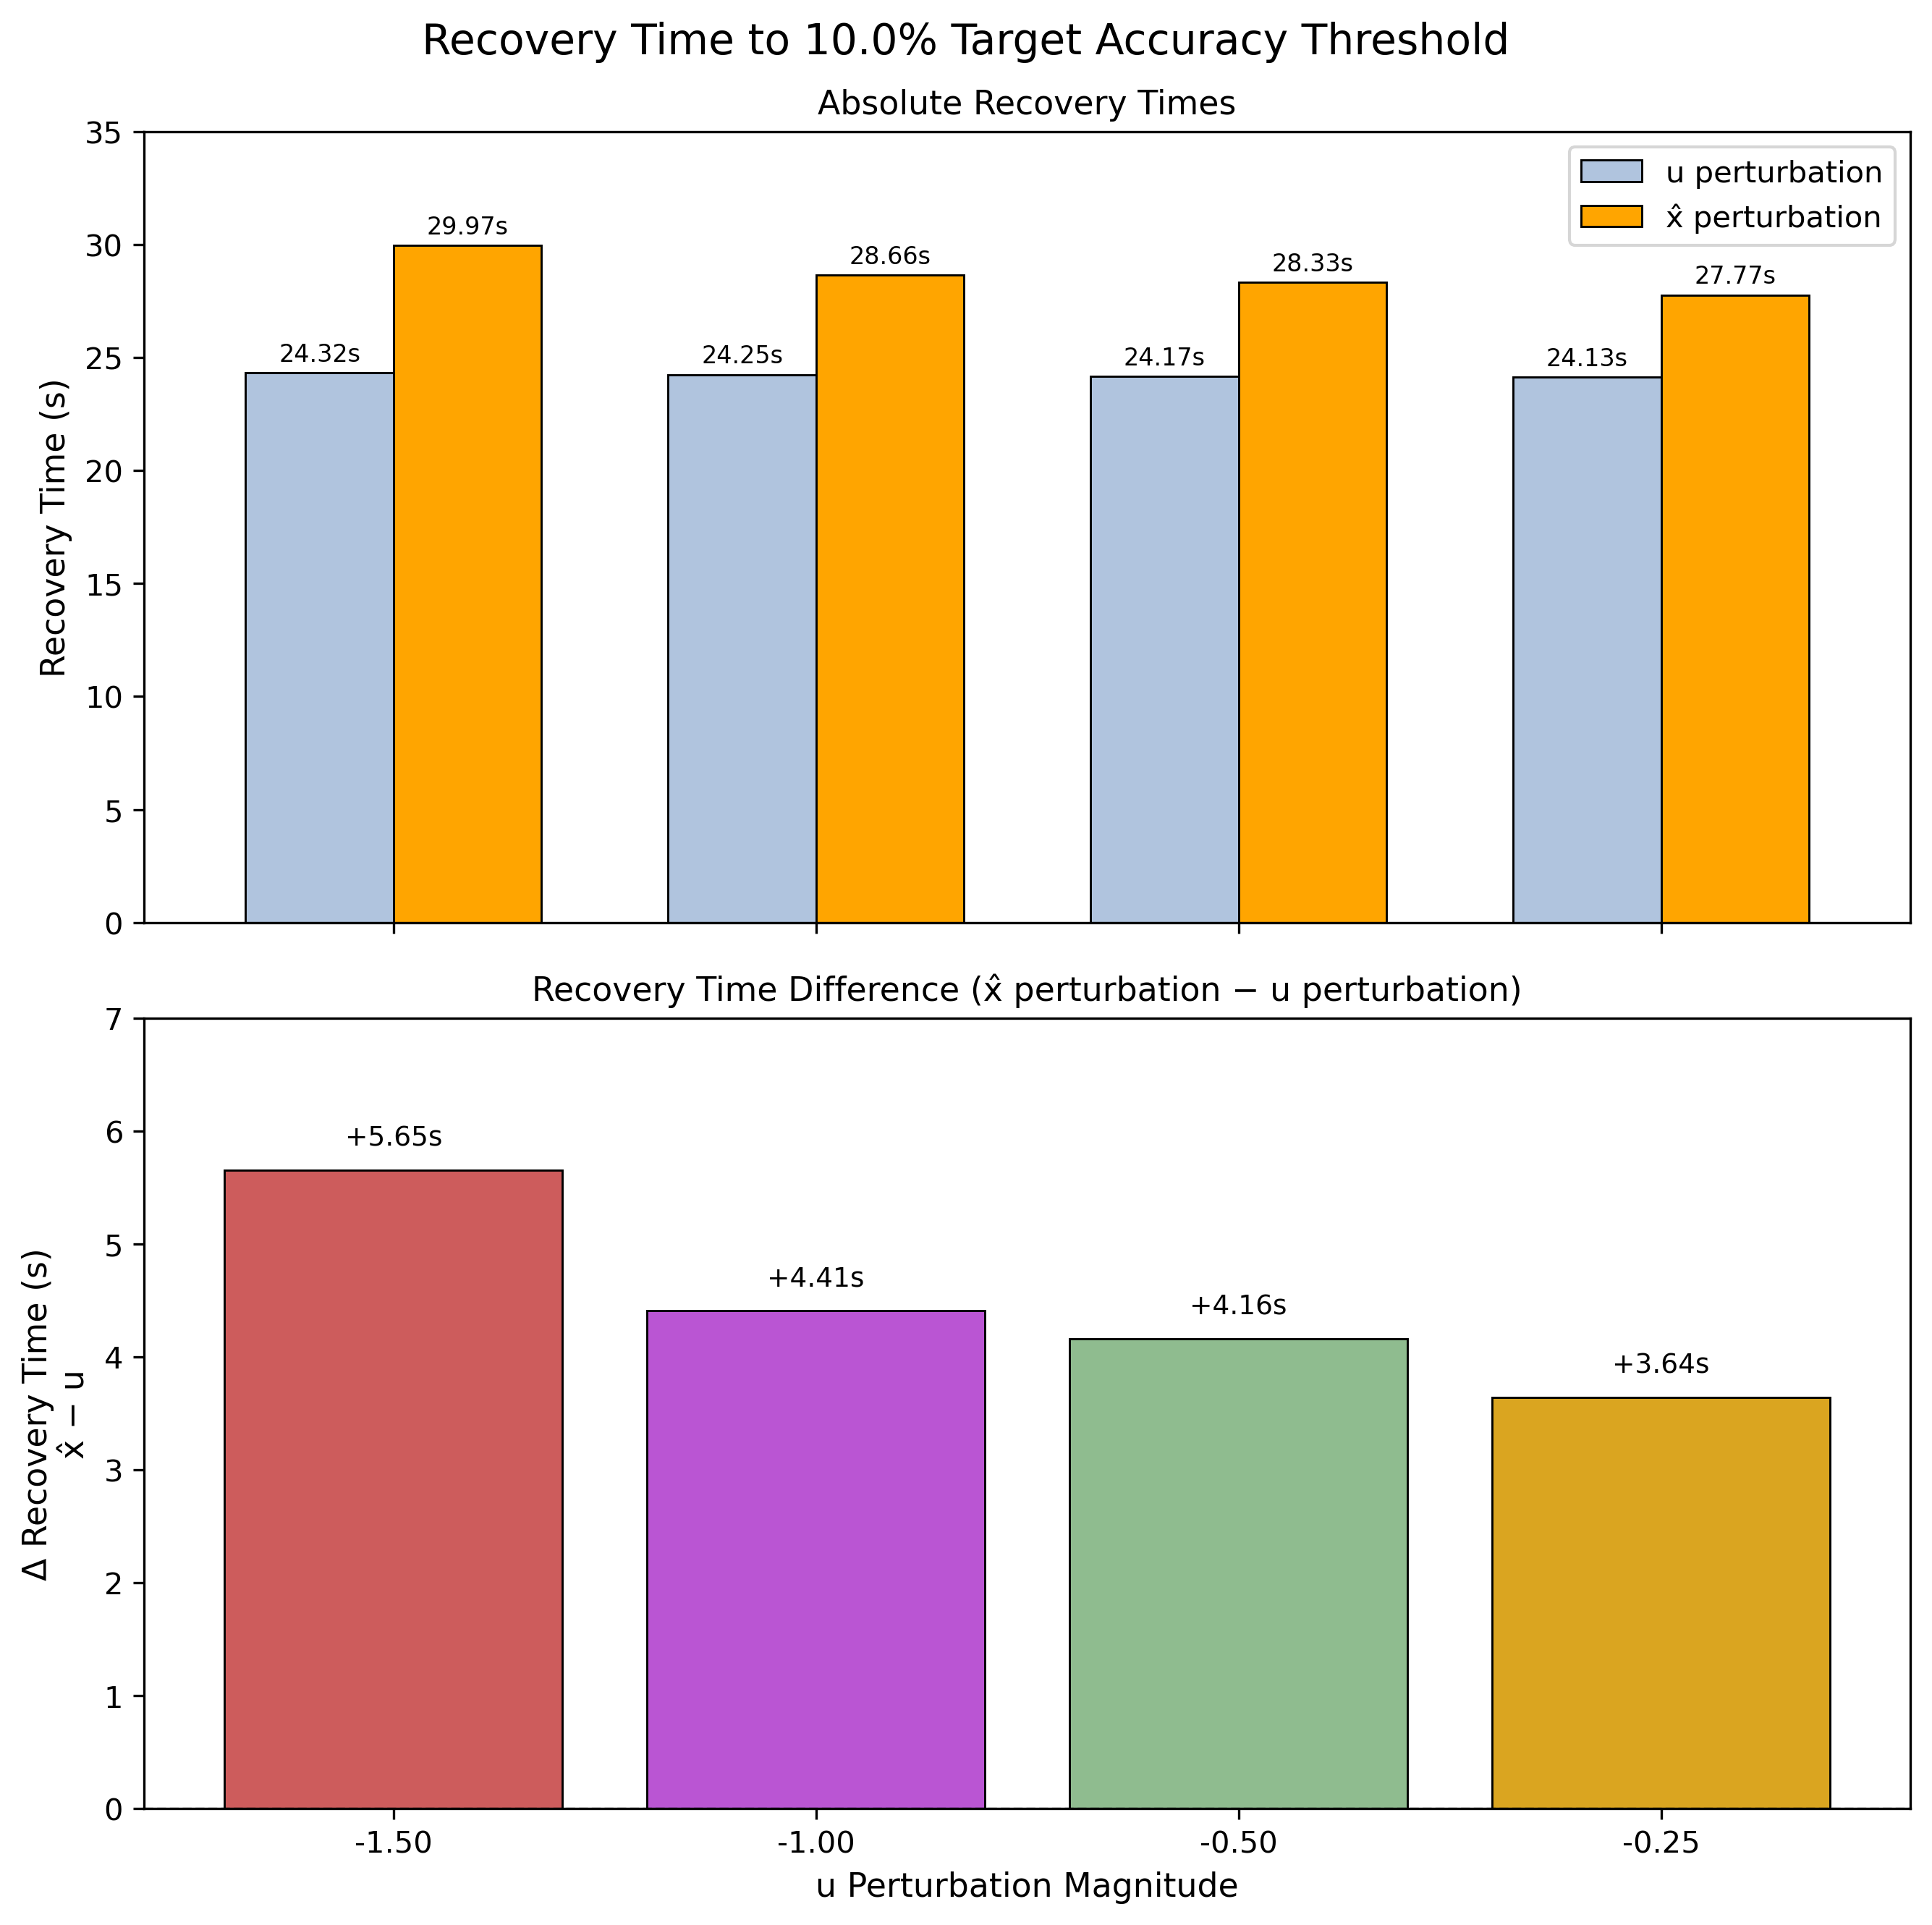

In [52]:
mag_labels = [f'{m:+.2f}' for m in u_pert_magnitudes]
x = np.arange(len(u_pert_magnitudes))
width = 0.35

fig, axes = plt.subplots(2, 1, figsize=(9, 9), sharex=True)
fig.suptitle(f'Recovery Time to {thr_pct}% Target Accuracy Threshold', fontsize=14)

# top: absolute recovery times
ax = axes[0]
bars_u    = ax.bar(x - width/2, rec_times_u,    width, label='u perturbation',
                   color='lightsteelblue', edgecolor='k', linewidth=0.7)
bars_xhat = ax.bar(x + width/2, rec_times_xhat, width, label='x̂ perturbation',
                   color='orange',    edgecolor='k', linewidth=0.7)

max_val = np.nanmax(rec_times_u + rec_times_xhat)
for bar, val in zip(list(bars_u) + list(bars_xhat), rec_times_u + rec_times_xhat):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max_val * 0.01,
                f'{val:.2f}s', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Recovery Time (s)', fontsize=11)
ax.set_ylim(0, 35)
ax.set_title('Absolute Recovery Times', fontsize=11)
ax.legend(fontsize=10)
#ax.grid(True, alpha=0.3, axis='y')

# bottom: difference (x̂ − u)
ax = axes[1]
#colors = ['seagreen' if d >= 0 else 'tomato' for d in rec_diff]
bars_diff = ax.bar(x, rec_diff, color=COLORS[2:], edgecolor='k', linewidth=0.7)
ax.axhline(0, color='k', linewidth=0.8, linestyle='--', alpha=0.6)

for bar, val in zip(bars_diff, rec_diff):
    offset = abs(max(rec_diff, key=abs)) * 0.03
    va = 'bottom' if val >= 0 else 'top'
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + (offset if val >= 0 else -offset),
            f'{val:+.2f}s', ha='center', va=va, fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(mag_labels)
ax.set_ylim(0, 7)
ax.set_xlabel('u Perturbation Magnitude', fontsize=11)
ax.set_ylabel('Δ Recovery Time (s)\nx̂ − u', fontsize=11)
ax.set_title('Recovery Time Difference (x̂ perturbation − u perturbation)', fontsize=11)
#ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

